In [41]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, SystemMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver

import requests
import random
import operator
from langgraph.types import interrupt
from langgraph.types import Command



In [4]:
model=ChatGroq(model='llama-3.1-8b-instant',api_key='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')


In [9]:
class chat_state(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [11]:
# def define
def chat_node(state:chat_state):
    decision = interrupt({
        "type":"approval",
        "reason": "Model is about to answere a user question",
        "question": state["messages"][-1].content,
        "instruction" : "Approve this question? yes/no"
        
    })
    if decision["approved"] =="no":
        return {"messages":[AIMessage(content="NOt approved.")]}
    else:
        response = model.invoke(state["messages"])
        return {"messages":[response]}

In [15]:
# build the graph
builder = StateGraph(chat_state)

# add_node
builder.add_node("chat", chat_node)

# add_edges
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# add memory
memory = MemorySaver()
app =builder.compile(checkpointer=memory)

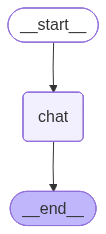

In [17]:
app

In [71]:
# create a new thread id for this conversation
config = {"configurable": {"thread_id":"1234"}}

initial_input = {
    "messages": [
        ("user", "Explain gradient Descent in very simple terms.")
        
    ]
}
# invoke the graph for the first time
result=app.invoke(initial_input, config=config)

In [73]:
message=result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answere a user question',
 'question': 'Explain gradient Descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [ ]:
user_input = input(f"\n Backend message - {message}\n Approved this question? (y/n:")


In [77]:
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

In [79]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient Descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='f088c037-d97b-4aa3-877e-dac8a93c2a2b'), HumanMessage(content='Explain gradient Descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='62749ddc-6b81-4e18-8fa4-f2587f4671f6'), AIMessage(content='**Gradient Descent in Simple Terms**\n\nImagine you\'re trying to find the lowest point in a big hill. You don\'t know exactly where it is, but you want to get there. Here\'s how gradient descent works:\n\n1. **Start at the top**: You begin at the highest point of the hill (or a random point).\n2. **Look down**: You look at the hill and try to figure out which direction is downhill. This is like calculating the "slope" of the hill.\n3. **Move a little**: You take a small step in the direction you think is downhill.\n4. **Check again**: You look at the hill again and try to figure out where you are now. If you\'re still not at the lowest poin